In [342]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

Task 1

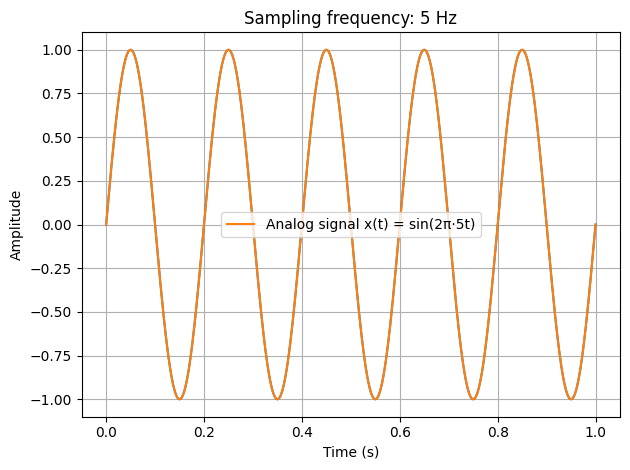

In [343]:
f0=5
t=np.linspace(0,1,1000)
x_t=np.sin(2*np.pi*f0*t)

plt.plot(t, x_t, label='')
plt.plot(t, x_t, label='Analog signal x(t) = sin(2π·5t)')
plt.title(f'Sampling frequency: {f0} Hz')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

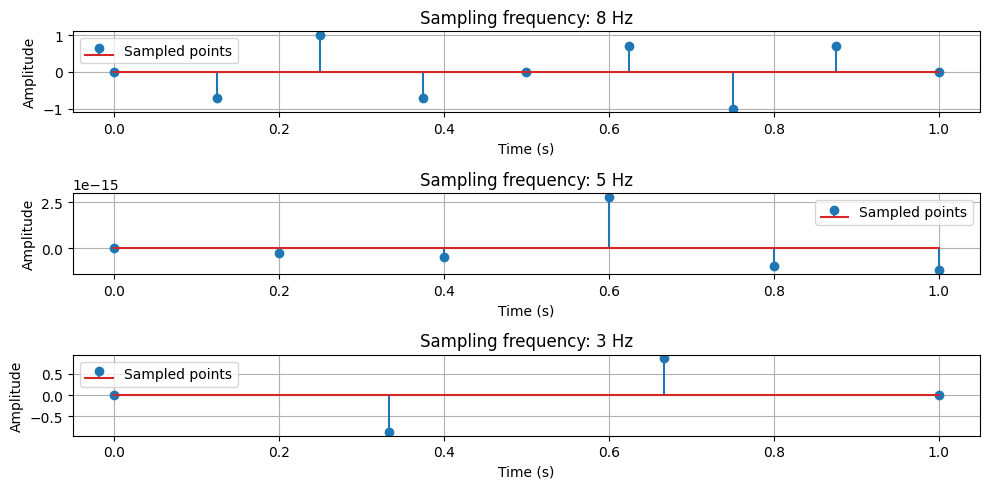

In [344]:
fs_values=[8,5,3]

plt.figure(figsize=(10,5))

n=[]

for i, fs in enumerate(fs_values):
  Ts=1/fs
  n=np.arange(0, 1+Ts, Ts)
  x_n=np.sin(2*np.pi*n*f0)

  plt.subplot(3,1,i+1)

  plt.stem(n, x_n, label='Sampled points')

  plt.title(f'Sampling frequency: {fs} Hz')
  plt.xlabel('Time (s)')
  plt.ylabel('Amplitude')
  plt.grid(True)
  plt.legend()

plt.tight_layout()
plt.show()


/tmp/ipykernel_7306/3880946051.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


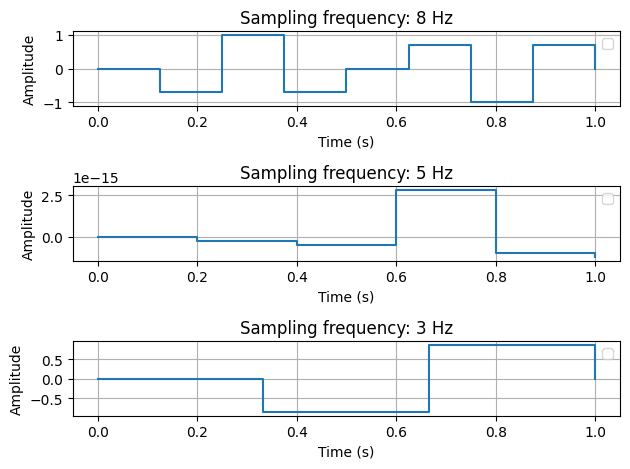

In [345]:
for i, fs in enumerate(fs_values):

  Ts=1/fs
  n=np.arange(0, 1+Ts, Ts)
  x_n=np.sin(2*np.pi*n*f0)

  t_zoh = np.repeat(n, 2)[1:]
  x_zoh = np.repeat(x_n, 2)[:-1]

  #values held(copied 2x from n and removed vals) to generate staircase like shape

  plt.subplot(3,1,i+1)

  plt.step(t_zoh, x_zoh)

  plt.title(f'Sampling frequency: {fs} Hz')
  plt.xlabel('Time (s)')
  plt.ylabel('Amplitude')
  plt.grid(True)
  plt.legend()

plt.tight_layout()
plt.show()

Task 2

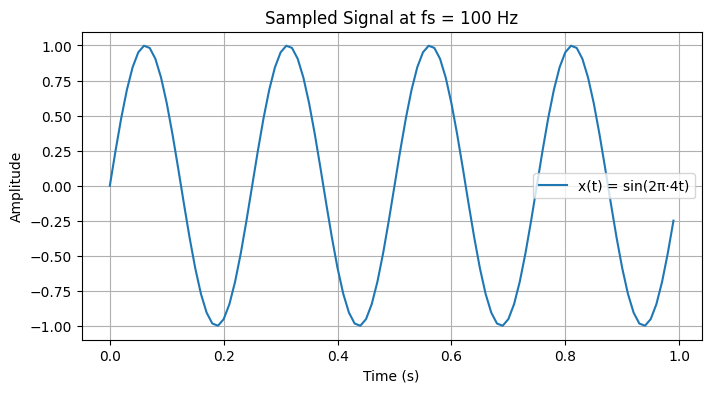

In [346]:
f0 = 4
fs = 100

t = np.arange(0, 1, 1/fs)
x = np.sin(2 * np.pi * f0 * t)

plt.figure(figsize=(8, 4))
plt.plot(t, x, label='x(t) = sin(2π·4t)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Sampled Signal at fs = 100 Hz')

plt.grid(True)
plt.legend()

plt.show()


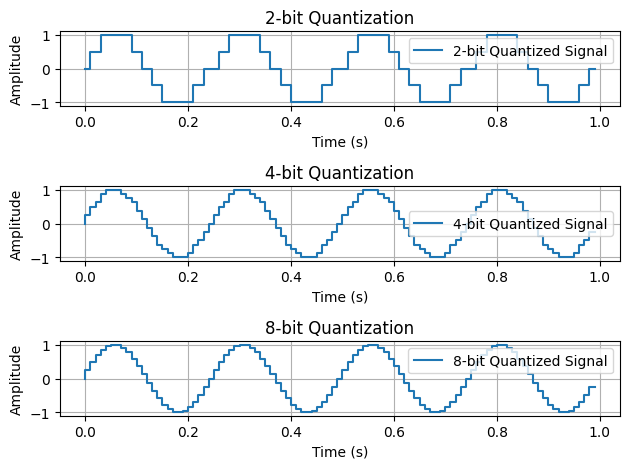

In [347]:
bit_values = [2, 4, 8]

for i, B in enumerate(bit_values):

    L = 2 ** B

    xmin = -1
    xmax = 1

    delta = (xmax - xmin) / L #quantized

    xq = delta * np.round(x / delta)

    plt.subplot(3, 1, i + 1)
    plt.step(t, xq, label=f'{B}-bit Quantized Signal')

    plt.title(f'{B}-bit Quantization')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')

    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.show()


2-bit Quantizer
Measured SQNR: 14.42 dB
Theoretical SQNR: 13.80 dB

4-bit Quantizer
Measured SQNR: 27.84 dB
Theoretical SQNR: 25.84 dB

8-bit Quantizer
Measured SQNR: 51.41 dB
Theoretical SQNR: 49.92 dB



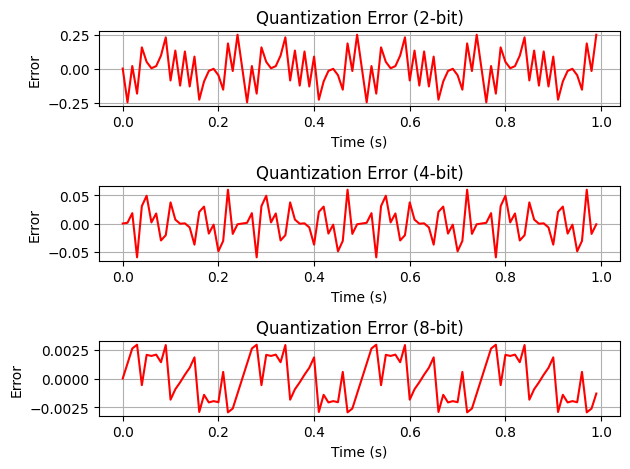

In [348]:
for i, B in enumerate(bit_values):

    L = 2 ** B

    xmin = -1
    xmax = 1

    delta = (xmax - xmin) / L
    xq = delta * np.round(x / delta)

    e = xq - x #error in quantization

    signal_power = np.mean(x ** 2)
    noise_power = np.mean(e ** 2)

    SQNR_measured = 10 * np.log10(signal_power / noise_power)

    SQNR_theoretical = 1.76 + 6.02 * B

    print(f"{B}-bit Quantizer")
    print(f"Measured SQNR: {SQNR_measured:.2f} dB")
    print(f"Theoretical SQNR: {SQNR_theoretical:.2f} dB")
    print()

    plt.subplot(3, 1, i + 1) #each quantization error plot

    plt.plot(t, e, color='red')

    plt.title(f'Quantization Error ({B}-bit)')
    plt.xlabel('Time (s)')
    plt.ylabel('Error')

    plt.grid(True)

plt.tight_layout()
plt.show()

Task 3

In [349]:
n = np.arange(-2, 4)

x = n**2 - 1

In [350]:
table = pd.DataFrame({
    'n': n,
    'x[n]': x
})

print("Tabular Representation:")
print(table)

Tabular Representation:
   n  x[n]
0 -2     3
1 -1     0
2  0    -1
3  1     0
4  2     3
5  3     8


In [351]:
print("\nSequence Representation:")
print("x[n] = ", list(x))


Sequence Representation:
x[n] =  [np.int64(3), np.int64(0), np.int64(-1), np.int64(0), np.int64(3), np.int64(8)]


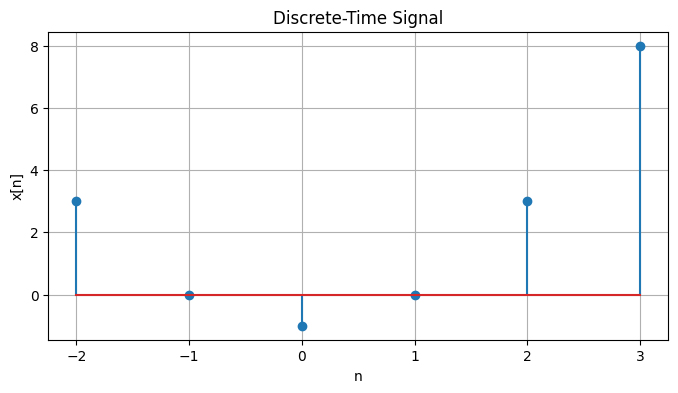

In [352]:
plt.figure(figsize=(8, 4))
plt.stem(n, x)
plt.title('Discrete-Time Signal')
plt.xlabel('n')
plt.ylabel('x[n]')
plt.grid(True)
plt.show()

Task 4

<StemContainer object of 3 artists>

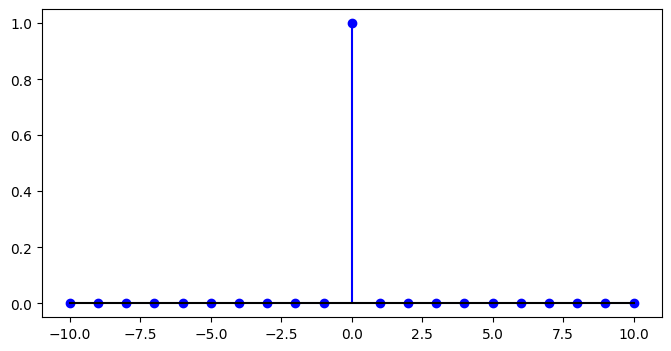

In [353]:
n = np.arange(-10, 11)

delta = np.where(n == 0, 1, 0)

plt.figure(figsize=(8, 4))

plt.stem(n, delta, linefmt='b-', markerfmt='bo',basefmt='k-', label='δ[n]')

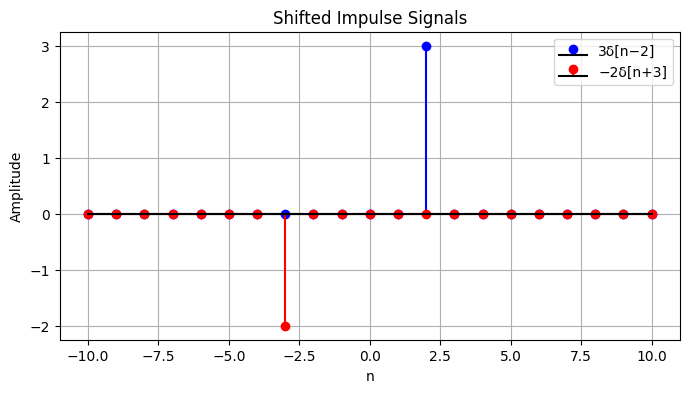

In [354]:
delta1 = 3 * np.where(n == 2, 1, 0)

delta2 = -2 * np.where(n == -3, 1, 0)

plt.figure(figsize=(8, 4))

plt.stem(n, delta1, linefmt='b-', markerfmt='bo',basefmt='k-', label='3δ[n−2]')

plt.stem(n, delta2, linefmt='r-', markerfmt='ro',basefmt='k-', label='−2δ[n+3]')

plt.title('Shifted Impulse Signals')
plt.xlabel('n')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()
plt.show()


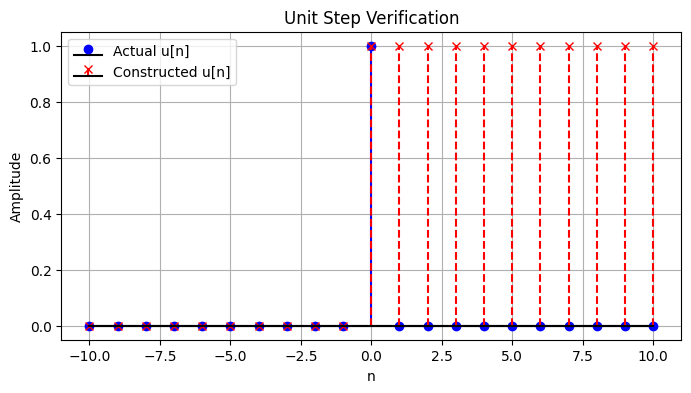

In [355]:
u = np.where(n == 0, 1, 0)

u_constructed = np.zeros_like(n)

for k in range(0, 11):
    u_constructed += np.where(n - k == 0, 1, 0)

plt.figure(figsize=(8, 4))

plt.stem(n, u, linefmt='b-', markerfmt='bo',basefmt='k-', label='Actual u[n]')

plt.stem(n, u_constructed, linefmt='r--', markerfmt='rx',basefmt='k-', label='Constructed u[n]')

plt.title('Unit Step Verification')
plt.xlabel('n')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()
plt.show()

Task 5

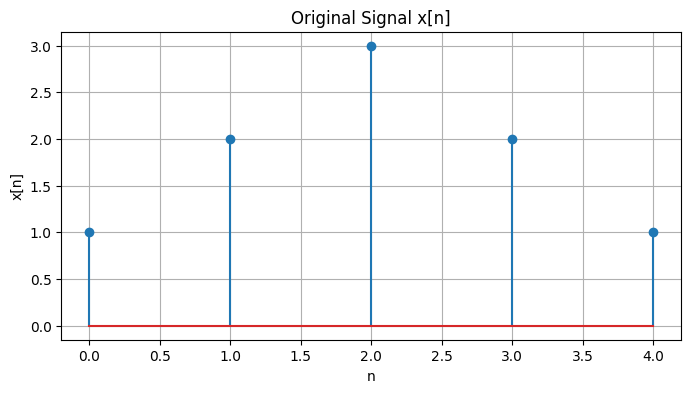

In [356]:
x = np.array([1, 2, 3, 2, 1])

n = np.arange(0, len(x))

plt.figure(figsize=(8, 4))
plt.stem(n, x)
plt.title('Original Signal x[n]')
plt.xlabel('n')
plt.ylabel('x[n]')
plt.grid(True)
plt.show()

In [357]:
n1 = n + 3
n2 = n - 2

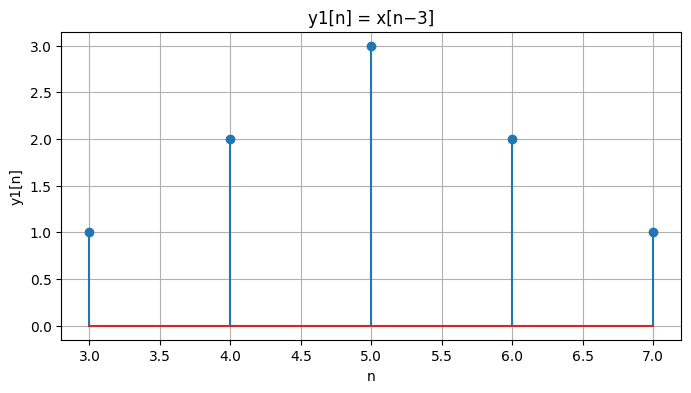

In [358]:
plt.figure(figsize=(8, 4))

plt.stem(n1, x)
plt.title('y1[n] = x[n−3]')
plt.xlabel('n')
plt.ylabel('y1[n]')
plt.grid(True)
plt.show()


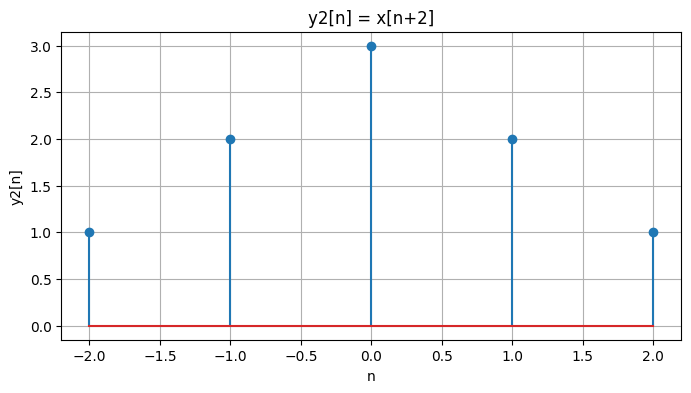

In [359]:
plt.figure(figsize=(8, 4))
plt.stem(n2, x)
plt.title('y2[n] = x[n+2]')
plt.xlabel('n')
plt.ylabel('y2[n]')
plt.grid(True)
plt.show()

Task 6

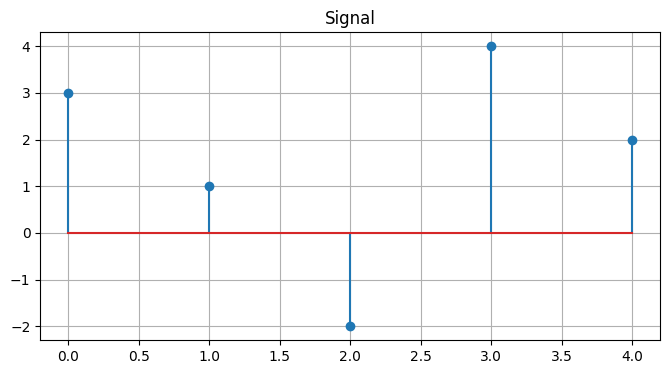

In [360]:
x = np.array([3, 1, -2, 4, 2])

n = np.arange(len(x))

plt.figure(figsize=(8, 4))
plt.stem(n, x)
plt.title('Signal')
plt.grid(True)

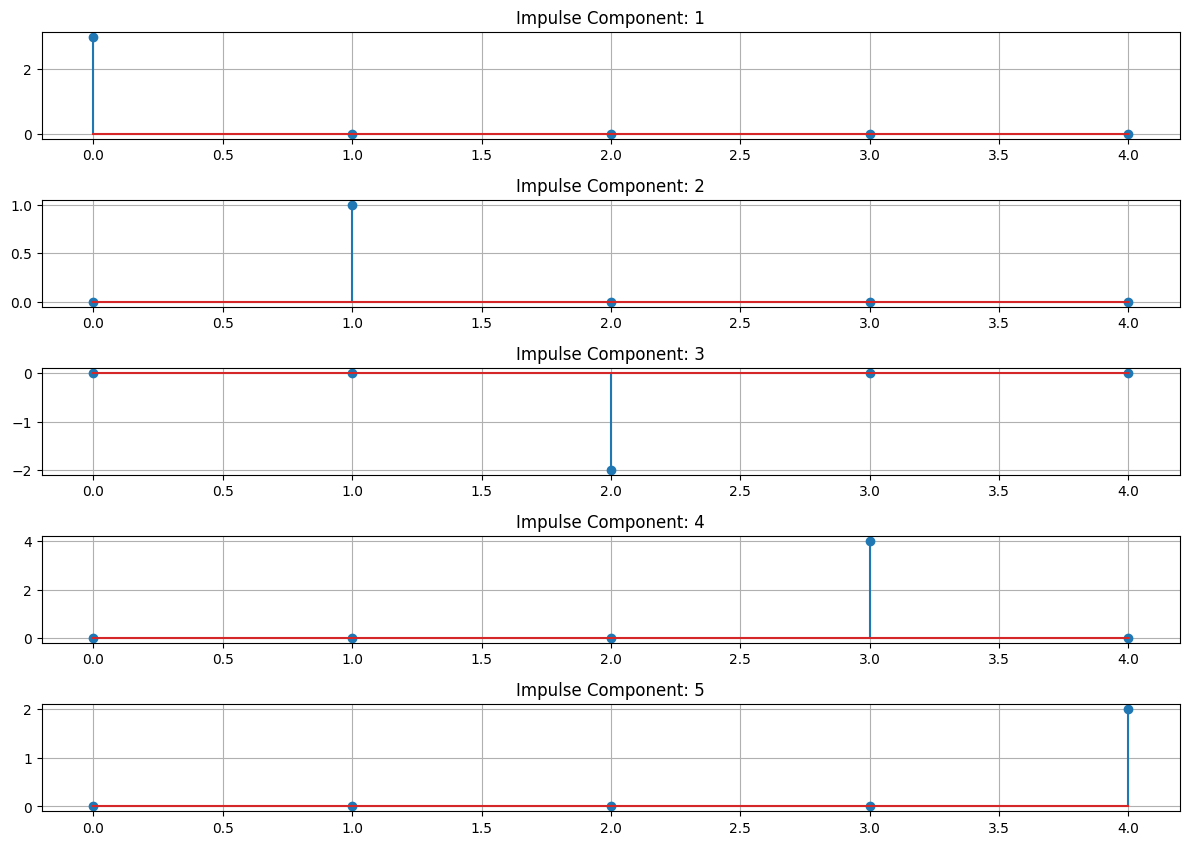

In [361]:
plt.figure(figsize=(12, 10))

for i in range(len(x)):
  component = np.zeros_like(x)

  component[i] = x[i]

  plt.subplot(len(x)+1, 1, i+1)
  plt.stem(n, component)
  plt.title(f'Impulse Component: {i+1}')
  plt.grid(True)

plt.tight_layout()
plt.show()

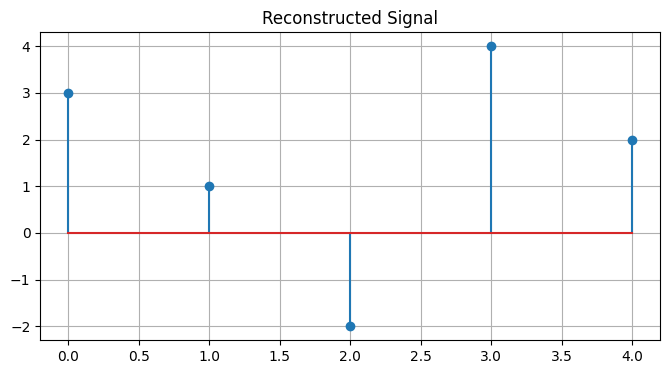

In [362]:
reconstructed = np.zeros_like(x)

for i in range(len(x)):
    reconstructed[i] = x[i]

plt.figure(figsize=(8, 4))
plt.stem(n, reconstructed)
plt.title('Reconstructed Signal')
plt.grid(True)

Task 7

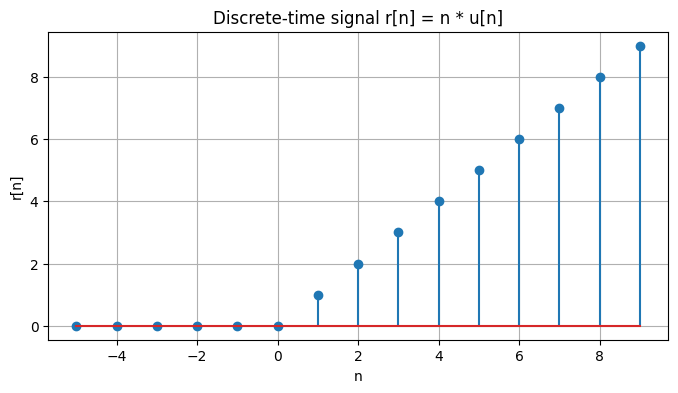

In [363]:
n = np.arange(-5, 10)
u = np.where(n >= 0, 1, 0)
r = n * u

plt.figure(figsize=(8, 4))
plt.stem(n, r)
plt.xlabel('n')
plt.ylabel('r[n]')
plt.title('Discrete-time signal r[n] = n * u[n]')
plt.grid(True)
plt.show()